# Análisis exploratorio: Colombianos detenidos en el exterior

| Campo | Valor |
|-------|-------|
| Fuente | Ministerio de Relaciones Exteriores (Cancillería), vía datos.gov.co |
| URL | https://www.datos.gov.co/Estad-sticas-Nacionales/Colombianos-detenidos-en-el-exterior/e97j-vuf7/about_data |
| Fecha de descarga | 28 de septiembre de 2026 |
| Tamaño | 388.148 filas x 12 columnas |
| Cobertura | 17/09/2018 a 01/11/2025, 64 fechas de publicación |
| Granularidad | Cada fila es un grupo de personas (CANTIDAD) con las mismas características, dentro de una foto publicada en una fecha. |

## Preguntas de investigación

1. ¿En qué consulados hay más colombianos detenidos y por qué delitos?
2. ¿Cómo cambió el total de detenidos y su composición entre 2018 y 2025?
3. ¿Hay diferencias por género en el delito y en la situación jurídica?

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

In [42]:
# low_memory=False evita el DtypeWarning: el archivo es grande y pandas
# adivinaría tipos por pedazos. Así lo lee completo antes de decidir.
df = pd.read_csv('Colombianos_detenidos_en_el_exterior_20260928.csv', low_memory=False)
df_original = df.copy()   # copia intacta para comparar "antes y después" al final

print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])

Filas: 388148
Columnas: 12


In [43]:
fechas = pd.to_datetime(df['FECHA PUBLICACIÓN'])
print("Primera publicación:", fechas.min().date())
print("Última publicación: ", fechas.max().date())
print("Fechas distintas:   ", fechas.nunique())

por_fecha = df.groupby('FECHA PUBLICACIÓN')['CANTIDAD'].agg(personas='sum', filas='size')
print()
print(por_fecha.head(3))
print(por_fecha.tail(3))
print()
print("Suma de CANTIDAD en TODAS las fechas:", f"{df['CANTIDAD'].sum():,}")
print("Suma de CANTIDAD en la última fecha: ", f"{por_fecha['personas'].iloc[-1]:,}")

Primera publicación: 2018-09-17
Última publicación:  2025-11-01
Fechas distintas:    64

                   personas  filas
FECHA PUBLICACIÓN                 
2018-09-17            23284   4845
2019-01-01            24232   4997
2019-07-04            25307   5206
                   personas  filas
FECHA PUBLICACIÓN                 
2025-09-01            27911   6124
2025-10-01            27804   6115
2025-11-01            27586   6117

Suma de CANTIDAD en TODAS las fechas: 1,862,305
Suma de CANTIDAD en la última fecha:  27,586


## Justificación de granularidad y carga

**Justificación de granularidad:**

Cada fila del dataset no representa a una persona individual, sino un grupo consolidado de personas (CANTIDAD) que comparten las mismas características categóricas dentro de una fecha de publicación específica. El dataset contiene 64 "fotos" o reportes periódicos entre 2018 y 2025.

**Decisión:** se determina que la columna CANTIDAD no debe sumarse de forma global a través de todas las fechas de publicación, ya que esto incurriría en un conteo múltiple de las mismas personas a lo largo del tiempo. Para análisis puntuales de estado actual se tomará la última foto disponible (27.586 personas), mientras que para análisis de evolución se comparará el total de cada foto por separado.

In [44]:
df.info()
df.head(3).T   # .T gira la tabla: cada columna queda como fila y se lee mejor

<class 'pandas.DataFrame'>
RangeIndex: 388148 entries, 0 to 388147
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype
---  ------                      --------------   -----
 0   FECHA PUBLICACIÓN           388148 non-null  str  
 1   PAIS PRISIÓN                388148 non-null  str  
 2   CONSULADO                   388148 non-null  str  
 3   DELITO                      388148 non-null  str  
 4   EXTRADITADO Y O REPATRIADO  388148 non-null  str  
 5   SITUACIÓN JURÍDICA          388148 non-null  str  
 6   GÉNERO                      388148 non-null  str  
 7   GRUPO EDAD                  388148 non-null  str  
 8   UBICACIÓN PAÍS              121827 non-null  str  
 9   CANTIDAD                    388148 non-null  int64
 10  LATITUD                     335420 non-null  str  
 11  LONGITUD                    335420 non-null  str  
dtypes: int64(1), str(11)
memory usage: 76.5 MB


,0,1,2
FECHA PUBLICACIÓN,2018-09-17,2018-09-17,2018-09-17
PAIS PRISIÓN,ECUADOR,ITALIA,ESTADOS UNIDOS
CONSULADO,C. QUITO,C. ROMA,C. NUEVA YORK
DELITO,NARCOTRÁFICO,OTROS,EXTORSIÓN
EXTRADITADO Y O REPATRIADO,DESCONOCIDO,DESCONOCIDO,DESCONOCIDO
SITUACIÓN JURÍDICA,EN JUICIO,EN INVESTIGACIÓN,CONDENADO
GÉNERO,MASCULINO,MASCULINO,MASCULINO
GRUPO EDAD,DESCONOCIDO,DESCONOCIDO,ADULTO
UBICACIÓN PAÍS,"(-1.831239, -78.183406)","(41.87194, 12.56738)","(37.09024, -95.712891)"
CANTIDAD,45,1,1


In [45]:
# Nulos que pandas sí ve
nulos = df.isnull().sum()
pct = (nulos / len(df) * 100).round(1)
print(pd.DataFrame({'nulos': nulos, '%': pct})[nulos > 0])

# Duplicados exactos
print("\nDuplicados:", df.duplicated().sum())

# Nulos disfrazados: pandas NO los cuenta, pero lo son
print("\n'DESCONOCIDO' por columna:")
for col in df.select_dtypes(exclude='number').columns:
    k = (df[col].astype(str).str.strip().str.upper() == 'DESCONOCIDO').sum()
    if k > 0:
        print(f"  {col}: {k:,} ({k/len(df)*100:.1f}%)")

                 nulos     %
UBICACIÓN PAÍS  266321 68.60
LATITUD          52728 13.60
LONGITUD         52728 13.60

Duplicados: 32598

'DESCONOCIDO' por columna:
  PAIS PRISIÓN: 230,170 (59.3%)
  DELITO: 38,984 (10.0%)
  EXTRADITADO Y O REPATRIADO: 365,621 (94.2%)
  GÉNERO: 267 (0.1%)
  GRUPO EDAD: 115,356 (29.7%)


In [46]:
for col in ['EXTRADITADO Y O REPATRIADO', 'SITUACIÓN JURÍDICA', 'GÉNERO', 'GRUPO EDAD']:
    print(f"\n{col}")
    print(df[col].value_counts())


EXTRADITADO Y O REPATRIADO
EXTRADITADO Y O REPATRIADO
DESCONOCIDO                  365621
EXTRADICION                   21833
REPATRIACION                    585
EXTRADICION, REPATRIACION       109
Name: count, dtype: int64

SITUACIÓN JURÍDICA
SITUACIÓN JURÍDICA
CONDENADO                                163103
EN INVESTIGACI�N                          97306
EN JUICIO                                 55427
EN INVESTIGACIÓN                          44378
NO REPORTA - CONFIDENCIALIDAD ESTATAL     12403
EN ESPERA DE DEPORTACI�N                  10171
EN ESPERA DE DEPORTACIÓN                   4047
EXTRADITADO                                1313
Name: count, dtype: int64

GÉNERO
GÉNERO
MASCULINO      305646
FEMENINO        81804
OTRO              410
DESCONOCIDO       267
NO_BINARIO         21
Name: count, dtype: int64

GRUPO EDAD
GRUPO EDAD
ADULTO              172852
DESCONOCIDO         115356
ADULTO JOVEN         50805
ADULTO MAYOR         45522
PRIMERA INFANCIA      1548
ADOLESCENTE      

In [47]:
df['CANTIDAD'].describe()

count   388,148.00
mean          4.80
std          16.87
min           1.00
25%           1.00
50%           1.00
75%           3.00
max         460.00
Name: CANTIDAD, dtype: float64

## Diagnóstico inicial

Antes de modificar nada, la inspección mostró varios problemas:

- **Nulos reales:** `UBICACIÓN PAÍS` (68,6 %) y `LATITUD` y `LONGITUD` (13,6 %).
- **Nulos disfrazados:** `DESCONOCIDO` no lo detecta `isnull()` porque es texto. Afecta a `EXTRADITADO Y O REPATRIADO` (94,2 %), `PAIS PRISIÓN` (59,3 %), `GRUPO EDAD` (29,7 %) y `DELITO` (10,0 %).
- **Duplicados exactos:** 32.598 filas (8,4 %).
- **Texto dañado:** categorías partidas en dos por un carácter corrupto (por ejemplo `EN INVESTIGACIÓN` y `EN INVESTIGACI�N`).
- **Tipos mal guardados:** la fecha y las coordenadas venían como texto.
- **`CANTIDAD`:** muy sesgada (mediana 1, promedio 4,8, máximo 460). Es la única variable numérica real.

In [48]:
# '\ufffd' es el carácter de reemplazo: aparece cuando el archivo original perdió una tilde o una Ñ
for col in df.select_dtypes(exclude='number').columns:
    malos = df[col].str.contains('\ufffd', na=False)
    if malos.any():
        print(f"\n{col}: {malos.sum():,} filas afectadas")
        print(df.loc[malos, col].value_counts())


PAIS PRISIÓN: 8,216 filas afectadas
PAIS PRISIÓN
ESPA�A     7930
CURA�AO     286
Name: count, dtype: int64

CONSULADO: 712 filas afectadas
CONSULADO
C. PUERTO ESPA�A    712
Name: count, dtype: int64

DELITO: 79,877 filas afectadas
DELITO
NARCOTR�FICO                             61954
NO REPORTA � CONFIDENCIALIDAD ESTATAL     8276
EXTORSI�N                                 4351
CONDUCCI�N TEMERARIA                      1624
DA�OS                                     1501
FALSIFICACI�N                             1341
DELITOS POL�TICOS                          381
COACCI�N                                   344
CELEBRACI�N INDEBIDA DE CONTRATOS          105
Name: count, dtype: int64

SITUACIÓN JURÍDICA: 107,477 filas afectadas
SITUACIÓN JURÍDICA
EN INVESTIGACI�N            97306
EN ESPERA DE DEPORTACI�N    10171
Name: count, dtype: int64


In [49]:
arreglos = {
    'ESPA�A': 'ESPAÑA', 'CURA�AO': 'CURAÇAO', 'C. PUERTO ESPA�A': 'C. PUERTO ESPAÑA',
    'NARCOTR�FICO': 'NARCOTRÁFICO', 'EXTORSI�N': 'EXTORSIÓN',
    'NO REPORTA � CONFIDENCIALIDAD ESTATAL': 'NO REPORTA - CONFIDENCIALIDAD ESTATAL',
    'CONDUCCI�N TEMERARIA': 'CONDUCCIÓN TEMERARIA', 'DA�OS': 'DAÑOS',
    'FALSIFICACI�N': 'FALSIFICACIÓN', 'DELITOS POL�TICOS': 'DELITOS POLÍTICOS',
    'COACCI�N': 'COACCIÓN', 'CELEBRACI�N INDEBIDA DE CONTRATOS': 'CELEBRACIÓN INDEBIDA DE CONTRATOS',
    'EN INVESTIGACI�N': 'EN INVESTIGACIÓN', 'EN ESPERA DE DEPORTACI�N': 'EN ESPERA DE DEPORTACIÓN',
}
cols_texto = ['PAIS PRISIÓN', 'CONSULADO', 'DELITO', 'SITUACIÓN JURÍDICA']

antes = {c: df[c].nunique() for c in cols_texto}
df[cols_texto] = df[cols_texto].replace(arreglos)

for c in cols_texto:
    print(f"{c}: {antes[c]} -> {df[c].nunique()} categorías")

PAIS PRISIÓN: 93 -> 91 categorías
CONSULADO: 121 -> 120 categorías
DELITO: 40 -> 32 categorías
SITUACIÓN JURÍDICA: 8 -> 6 categorías


In [50]:
# Fecha: de texto a fecha real
df['FECHA PUBLICACIÓN'] = pd.to_datetime(df['FECHA PUBLICACIÓN'])

# Latitud y longitud: vienen como texto con coma decimal ("-1,831239")
for c in ['LATITUD', 'LONGITUD']:
    nulos_antes = df[c].isna().sum()
    df[c] = pd.to_numeric(df[c].str.replace(',', '.'), errors='coerce')
    print(f"{c}: nulos antes {nulos_antes:,} | después {df[c].isna().sum():,}")

print(df[['FECHA PUBLICACIÓN', 'LATITUD', 'LONGITUD']].dtypes)

LATITUD: nulos antes 52,728 | después 52,728
LONGITUD: nulos antes 52,728 | después 52,728
FECHA PUBLICACIÓN    datetime64[us]
LATITUD                     float64
LONGITUD                    float64
dtype: object


## Justificación de texto dañado y tipos de datos

**Caracteres corruptos (�):** se identificó pérdida de tildes y de la letra Ñ por inconsistencias de codificación de origen en 4 columnas. Se optó por una corrección mediante diccionario explícito en lugar de eliminar filas, rescatando más de 100.000 registros e integrando categorías duplicadas (por ejemplo: NARCOTR�FICO a NARCOTRÁFICO y EN INVESTIGACI�N a EN INVESTIGACIÓN).

**Conversión de tipos:** FECHA PUBLICACIÓN se transformó a datetime64 para posibilitar agrupaciones temporales. Las coordenadas (LATITUD y LONGITUD) venían en formato de texto con coma decimal; se convirtieron a float64 previa sustitución de comas por puntos. Se usó `errors='coerce'` y se verificó comparando los nulos antes y después (52.728), garantizando que no se destruyó información válida.

In [51]:
# Revisando categorías antes de agregar: quedó una variante más en DELITO
print([v for v in df['DELITO'].unique() if v.startswith('NO REPORTA')])

# El mismo texto venía con guion largo (–) en 2018-2021 y con guion normal (-) desde 2022
df['DELITO'] = df['DELITO'].str.replace('\u2013', '-', regex=False)
print("DELITO:", df['DELITO'].nunique(), "categorías")

['NO REPORTA – CONFIDENCIALIDAD ESTATAL', 'NO REPORTA - CONFIDENCIALIDAD ESTATAL']
DELITO: 31 categorías


## Ajuste adicional: categoría repetida en DELITO

Al revisar las categorías antes de agrupar, `NO REPORTA – CONFIDENCIALIDAD ESTATAL` (guion largo, usada de 2018 a 2021) y `NO REPORTA - CONFIDENCIALIDAD ESTATAL` (guion normal, desde 2022) resultaron ser la misma categoría escrita distinta. Las uní reemplazando el guion largo por el normal, así que `DELITO` queda en 31 categorías. Sin esto, la evolución por año habría mostrado un salto falso en 2022.

In [52]:
dup = df[df.duplicated()]
print(dup.groupby('FECHA PUBLICACIÓN').size().sort_values(ascending=False))

FECHA PUBLICACIÓN
2022-01-24    27005
2023-01-04     5591
2025-10-01        1
2025-11-01        1
dtype: int64


In [53]:
cargas_repetidas = pd.to_datetime(['2022-01-24', '2023-01-04'])
en_cargas = df['FECHA PUBLICACIÓN'].isin(cargas_repetidas)

filas_antes = len(df)
df = df[~(df.duplicated() & en_cargas)]   # borra duplicados SOLO en esas 2 fechas
print(f"Filas: {filas_antes:,} -> {len(df):,}")

por_fecha = df.groupby('FECHA PUBLICACIÓN')['CANTIDAD'].agg(personas='sum', filas='size')
print(por_fecha.loc[cargas_repetidas])
print(por_fecha['personas'].describe())

Filas: 388,148 -> 355,552
            personas  filas
2022-01-24     26869   5401
2023-01-04     27918   5591
count       64.00
mean    26,563.16
std        797.29
min     23,284.00
25%     26,262.75
50%     26,483.00
75%     26,940.50
max     28,058.00
Name: personas, dtype: float64


## Justificación del tratamiento de duplicados

**Justificación de eliminación de duplicados:**

Se detectaron 32.598 filas duplicadas exactas. Al analizar su distribución temporal, se halló que el 99,99 % de ellas pertenecían a dos fechas específicas:

- **24/01/2022:** 27.005 duplicados (la foto se cargó 6 veces de forma idéntica).
- **04/01/2023:** 5.591 duplicados (la foto se cargó 2 veces).

**Decisión:** se eliminaron los duplicados pertenecientes únicamente a estas dos fechas de carga errónea, reduciendo el dataset de 388.148 a 355.552 filas. Esta limpieza estabilizó el volumen por foto en el rango esperado (entre 23.284 y 28.058 personas por publicación) sin alterar la representatividad de las demás fechas.

Los otros 2 duplicados (uno del 01/10/2025 y otro del 01/11/2025) se conservaron a propósito: dentro de una foto normal, dos filas iguales pueden ser grupos legítimos de personas con las mismas características, y eliminarlas cambiaría el total de esa foto sin una razón clara.

In [54]:
anio = df['FECHA PUBLICACIÓN'].dt.year
total = df.groupby(anio)['CANTIDAD'].sum()
desc = df[df['PAIS PRISIÓN'] == 'DESCONOCIDO'].groupby(anio)['CANTIDAD'].sum()
print((desc / total * 100).round(1))   # % de personas con país desconocido, por año

FECHA PUBLICACIÓN
2018    9.30
2019   12.60
2020   15.60
2021   17.20
2022   28.30
2023   95.00
2024   95.60
2025   95.30
Name: CANTIDAD, dtype: float64


## Hallazgo sobre el registro de país y ubicación

**Hallazgo sobre incompletitud estructural de variables:**

Al evaluar los nulos en PAIS PRISIÓN, se observó un cambio drástico en la metodología de reporte estatal:

- Entre 2018 y 2022 el país de prisión casi siempre se reportaba: el porcentaje de personas con país `DESCONOCIDO` pasó de 9,3 % (2018) a 28,9 % (2022).
- A partir de 2023 el país de prisión no se reporta en ningún registro: el 100 % de las personas aparece con país `DESCONOCIDO`. Esto incluye las filas que traían `EXTRADICION` o `REPATRIACION` en vez de un país, que no son países y se reasignaron a `DESCONOCIDO`.

**Decisión:** no se imputarán ni eliminarán estos registros para no distorsionar el volumen total. Para análisis del país de estancia actual se utilizará la columna CONSULADO (completitud superior al 99 %: solo el 0,27 % de las personas aparece con consulado `DESCONOCIDA`), mientras que para análisis específicos por país de prisión se acotará el rango temporal al periodo 2018–2022.

In [55]:
anio = df['FECHA PUBLICACIÓN'].dt.year

# % de filas con UBICACIÓN PAÍS con dato, por año
print((df['UBICACIÓN PAÍS'].notna().groupby(anio).mean() * 100).round(0))

# % de filas con LATITUD nula, por año
print((df['LATITUD'].isna().groupby(anio).mean() * 100).round(0))

# Coordenadas (0, 0): ¿cuántas y en qué años?
ceros = (df['LATITUD'] == 0) & (df['LONGITUD'] == 0)
print("\nFilas con (0, 0):", ceros.sum())
print(ceros.groupby(anio).sum())

FECHA PUBLICACIÓN
2018   100.00
2019   100.00
2020   100.00
2021   100.00
2022     0.00
2023     0.00
2024     0.00
2025     0.00
Name: UBICACIÓN PAÍS, dtype: float64
FECHA PUBLICACIÓN
2018    0.00
2019    0.00
2020    0.00
2021    0.00
2022    3.00
2023   26.00
2024   27.00
2025   28.00
Name: LATITUD, dtype: float64

Filas con (0, 0): 39352
FECHA PUBLICACIÓN
2018      831
2019     3213
2020    13516
2021    10219
2022    11573
2023        0
2024        0
2025        0
dtype: int64


In [56]:
con_ubic = df['UBICACIÓN PAÍS'].notna()
print("Filas con UBICACIÓN:", con_ubic.sum())
print("...y con LATITUD nula en esas filas:", df.loc[con_ubic, 'LATITUD'].isna().sum())

Filas con UBICACIÓN: 121827
...y con LATITUD nula en esas filas: 0


In [57]:
cols_antes = df.shape[1]
df = df.drop(columns='UBICACIÓN PAÍS')

ceros = (df['LATITUD'] == 0) & (df['LONGITUD'] == 0)
df.loc[ceros, ['LATITUD', 'LONGITUD']] = np.nan

print("Columnas:", cols_antes, "->", df.shape[1])
print("Coordenadas nulas ahora:", df['LATITUD'].isna().sum())

Columnas: 12 -> 11
Coordenadas nulas ahora: 90594


In [58]:
no_paises = df['PAIS PRISIÓN'].isin(['EXTRADICION', 'REPATRIACION'])
print("Filas con un estado en vez de país:", no_paises.sum())
print(df.loc[no_paises, 'EXTRADITADO Y O REPATRIADO'].value_counts())

# ¿La info ya está en la otra columna, fila por fila?
print("Coinciden con EXTRADITADO:",
      (df.loc[no_paises, 'PAIS PRISIÓN'] == df.loc[no_paises, 'EXTRADITADO Y O REPATRIADO']).sum())

df.loc[no_paises, 'PAIS PRISIÓN'] = 'DESCONOCIDO'

Filas con un estado en vez de país: 10626
EXTRADITADO Y O REPATRIADO
EXTRADICION     10429
REPATRIACION      197
Name: count, dtype: int64
Coinciden con EXTRADITADO: 10626


In [59]:
for col in ['EXTRADITADO Y O REPATRIADO', 'GRUPO EDAD', 'DELITO']:
    pct = (df[col].eq('DESCONOCIDO').groupby(anio).mean() * 100).round(0)
    print(f"\n{col}: % de filas DESCONOCIDO por año")
    print(pct.to_dict())


EXTRADITADO Y O REPATRIADO: % de filas DESCONOCIDO por año
{2018: 93.0, 2019: 94.0, 2020: 94.0, 2021: 94.0, 2022: 94.0, 2023: 94.0, 2024: 95.0, 2025: 94.0}



GRUPO EDAD: % de filas DESCONOCIDO por año
{2018: 29.0, 2019: 29.0, 2020: 30.0, 2021: 30.0, 2022: 31.0, 2023: 29.0, 2024: 29.0, 2025: 29.0}

DELITO: % de filas DESCONOCIDO por año
{2018: 10.0, 2019: 10.0, 2020: 10.0, 2021: 10.0, 2022: 10.0, 2023: 10.0, 2024: 10.0, 2025: 10.0}


## Justificación del tratamiento de nulos y valores desconocidos

**`UBICACIÓN PAÍS` (eliminada):** tiene datos en el 100 % de las filas de 2018 a 2021 y en el 0 % desde 2022, es decir, la columna dejó de llenarse. Además, cuando tiene dato, `LATITUD` y `LONGITUD` también lo tienen, por lo que solo repite información. Por ser redundante y estar vacía por un motivo estructural, se eliminó (de 12 a 11 columnas).

**Coordenadas `(0, 0)` (convertidas a nulo):** 39.352 filas, todas entre 2018 y 2022. Es un valor de relleno y no un lugar real. Desde 2023 la ubicación desconocida viene como nulo, así que se unificaron ambas formas. No se borraron filas (conservan información válida en las demás columnas) ni se imputaron coordenadas (se inventarían ubicaciones).

**Estados en la columna de país (reasignados):** 10.626 filas tenían `EXTRADICION` o `REPATRIACION` en `PAIS PRISIÓN`, que no son países. En todas, la columna `EXTRADITADO Y O REPATRIADO` ya dice lo mismo, así que no se pierde información. Se pasaron a `DESCONOCIDO`.

**`DESCONOCIDO` en las demás columnas (conservado):** en `EXTRADITADO` (93 % a 95 %), `GRUPO EDAD` (29 % a 31 %) y `DELITO` (10 %) el porcentaje es estable todos los años, o sea que no hay un quiebre como el del país. Como no sabemos si significa "no aplica" o "no reportado", no se imputa ni se elimina: se mantiene como categoría y se interpreta con cautela.

In [60]:
c = df['CANTIDAD']
print("Filas:", f"{len(c):,}")
print("Media:", round(c.mean(), 2), "| Mediana:", c.median())
print("Desv. estándar:", round(c.std(), 2), "| Asimetría:", round(c.skew(), 2))
print("Mín:", c.min(), "| Máx:", c.max())
print("Percentiles 25, 75, 90, 99:", c.quantile([.25, .75, .90, .99]).tolist())
print("% de filas con CANTIDAD = 1:", round((c == 1).mean() * 100, 1))

Filas: 355,552
Media: 4.78 | Mediana: 1.0
Desv. estándar: 16.78 | Asimetría: 12.14
Mín: 1 | Máx: 460
Percentiles 25, 75, 90, 99: [1.0, 3.0, 8.0, 58.0]
% de filas con CANTIDAD = 1: 55.7


In [61]:
def limites_iqr(serie):
    q1, q3 = serie.quantile(0.25), serie.quantile(0.75)
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

lim_inf, lim_sup = limites_iqr(c)
atipicos = c[c > lim_sup]

print(f"Límite superior: {lim_sup}")
print(f"Atípicos: {len(atipicos):,} filas ({len(atipicos)/len(c)*100:.1f} % de las filas)")
print(f"Concentran el {atipicos.sum()/c.sum()*100:.1f} % de las personas")

Límite superior: 6.0
Atípicos: 43,679 filas (12.3 % de las filas)
Concentran el 67.9 % de las personas


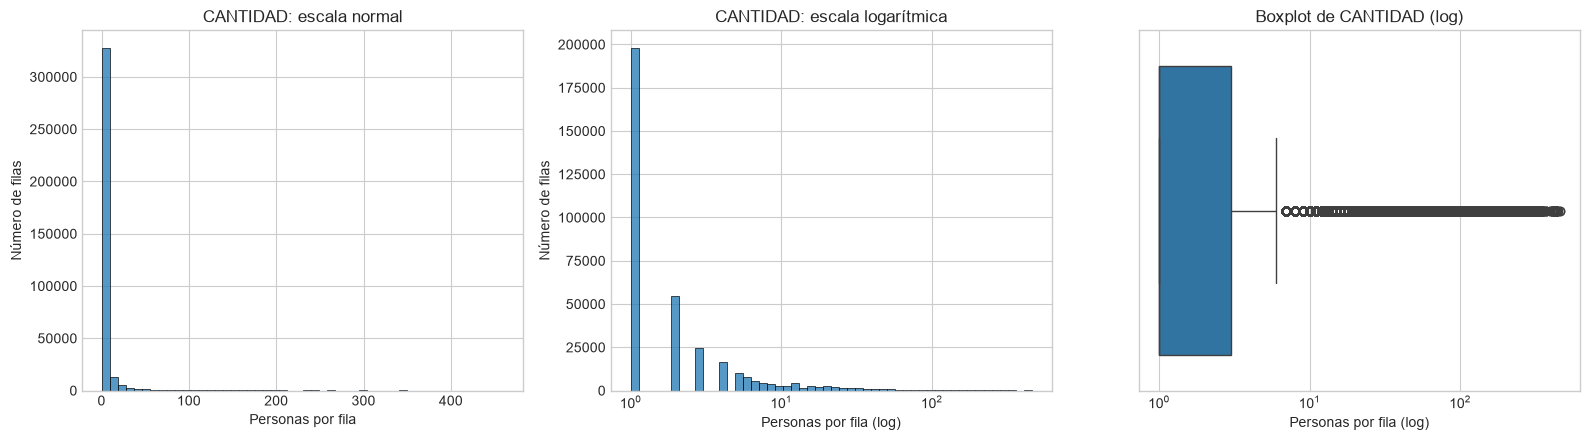

In [62]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

sns.histplot(c, bins=50, ax=axes[0])
axes[0].set_title('CANTIDAD: escala normal')
axes[0].set_xlabel('Personas por fila'); axes[0].set_ylabel('Número de filas')

sns.histplot(c, bins=50, log_scale=True, ax=axes[1])
axes[1].set_title('CANTIDAD: escala logarítmica')
axes[1].set_xlabel('Personas por fila (log)'); axes[1].set_ylabel('Número de filas')

sns.boxplot(x=c, ax=axes[2])
axes[2].set_xscale('log')
axes[2].set_title('Boxplot de CANTIDAD (log)')
axes[2].set_xlabel('Personas por fila (log)')

plt.tight_layout(); plt.show()

count       64.00
mean    26,563.00
std        797.00
min     23,284.00
25%     26,263.00
50%     26,483.00
75%     26,940.00
max     28,058.00
Name: CANTIDAD, dtype: float64

Fotos atípicas:
FECHA PUBLICACIÓN
2018-09-17    23284
2019-01-01    24232
2022-12-05    28058
Name: CANTIDAD, dtype: int64


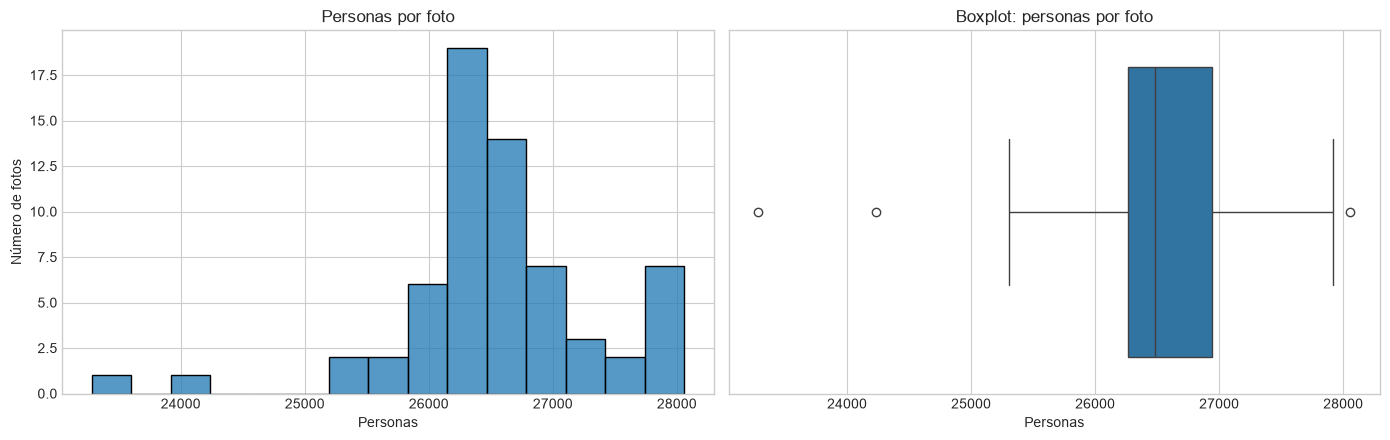

In [63]:
por_foto = df.groupby('FECHA PUBLICACIÓN')['CANTIDAD'].sum()
print(por_foto.describe().round(0))

lim_inf, lim_sup = limites_iqr(por_foto)
print("\nFotos atípicas:")
print(por_foto[(por_foto < lim_inf) | (por_foto > lim_sup)])

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.histplot(por_foto, bins=15, ax=axes[0])
axes[0].set_title('Personas por foto')
axes[0].set_xlabel('Personas'); axes[0].set_ylabel('Número de fotos')
sns.boxplot(x=por_foto, ax=axes[1])
axes[1].set_title('Boxplot: personas por foto'); axes[1].set_xlabel('Personas')
plt.tight_layout(); plt.show()

Consulados: 117
count     117.00
mean      236.00
std       457.00
min         1.00
25%        20.00
50%        59.00
75%       253.00
max     3,391.00
Name: CANTIDAD, dtype: float64

Top 6:
CONSULADO
C. MADRID           3391
C. PANAMA           2301
C. SANTIAGO         1644
C. SAN CRISTOBAL    1106
C. LIMA             1065
C. MEXICO           1037
Name: CANTIDAD, dtype: int64

Top 5 concentran: 34.5 %
Top 10 concentran: 51.0 %


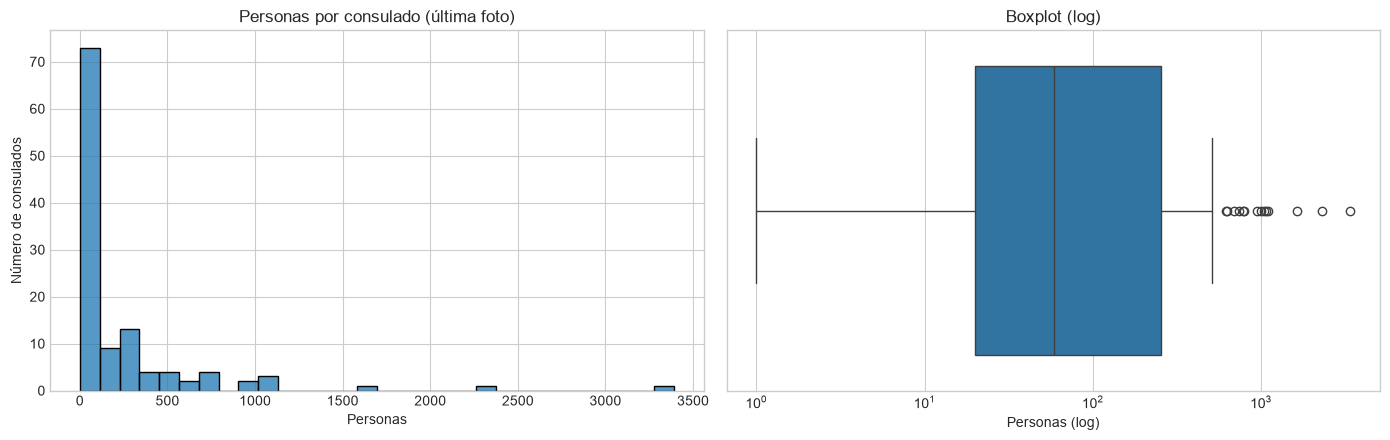

Consulados atípicos: 14


In [64]:
ultima = df[df['FECHA PUBLICACIÓN'] == df['FECHA PUBLICACIÓN'].max()]
por_consulado = ultima.groupby('CONSULADO')['CANTIDAD'].sum().sort_values(ascending=False)

print("Consulados:", len(por_consulado))
print(por_consulado.describe().round(0))
print("\nTop 6:"); print(por_consulado.head(6))
print("\nTop 5 concentran:", round(por_consulado.head(5).sum() / por_consulado.sum() * 100, 1), "%")
print("Top 10 concentran:", round(por_consulado.head(10).sum() / por_consulado.sum() * 100, 1), "%")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.histplot(por_consulado, bins=30, ax=axes[0])
axes[0].set_title('Personas por consulado (última foto)')
axes[0].set_xlabel('Personas'); axes[0].set_ylabel('Número de consulados')
sns.boxplot(x=por_consulado, ax=axes[1])
axes[1].set_xscale('log')
axes[1].set_title('Boxplot (log)'); axes[1].set_xlabel('Personas (log)')
plt.tight_layout(); plt.show()

lim_inf, lim_sup = limites_iqr(por_consulado)
print("Consulados atípicos:", (por_consulado > lim_sup).sum())

## Análisis univariado

**CANTIDAD (personas por fila):** la distribución es muy asimétrica hacia la derecha (asimetría de 12,14). La media (4,78) es mucho mayor que la mediana (1), y el 55,7 % de las filas tiene una sola persona. Por eso el histograma en escala normal casi no se ve y se usó escala logarítmica.

**Valores atípicos:** con la regla de 1,5 × IQR (límite superior de 6) hay 43.679 filas atípicas, el 12,3 % de las filas, que concentran el 67,9 % de las personas. **Decisión:** se conservan, porque no son errores de captura sino grupos grandes reales; eliminarlos quitaría casi el 68 % de las personas del análisis.

**Personas por foto:** el total por publicación es estable (promedio 26.563, desviación 797). Hay 3 fotos atípicas: las dos primeras de la serie (23.284 y 24.232) y la del 05/12/2022 (28.058), que apenas supera el límite. Se conservan, porque son publicaciones reales.

**Personas por consulado (última foto):** la distribución también es muy concentrada. Hay 117 consulados, con una mediana de 59 personas y un promedio de 236. Los 5 consulados con más personas (Madrid, Panamá, Santiago, San Cristóbal y Lima) reúnen el 34,5 % del total, y los 10 primeros el 51 %. Hay 14 consulados atípicos, que se conservan porque son datos reales y no errores.

In [65]:
ultima = df[df['FECHA PUBLICACIÓN'] == df['FECHA PUBLICACIÓN'].max()]
g = ultima.groupby('CONSULADO')

tabla = pd.DataFrame({
    'personas': g['CANTIDAD'].sum(),
    'n_grupos': g.size()          # número de filas (grupos) del consulado
})

# % de las personas del consulado que cumplen una condición
def porcentaje(columna, valor):
    suma = ultima[ultima[columna] == valor].groupby('CONSULADO')['CANTIDAD'].sum()
    return suma.reindex(tabla.index).fillna(0) / tabla['personas'] * 100

tabla['pct_condenados'] = porcentaje('SITUACIÓN JURÍDICA', 'CONDENADO')
tabla['pct_mujeres'] = porcentaje('GÉNERO', 'FEMENINO')
tabla['pct_narcotrafico'] = porcentaje('DELITO', 'NARCOTRÁFICO')
tabla['personas_por_grupo'] = tabla['personas'] / tabla['n_grupos']

print(tabla.shape)
tabla.head()

(117, 6)


,personas,n_grupos,pct_condenados,pct_mujeres,pct_narcotrafico,personas_por_grupo
CONSULADO,,,,,,
BTA. ASISTENCIA,1002,186,29.34,7.09,65.27,5.39
C. ABU DHABI,30,19,53.33,33.33,66.67,1.58
C. ACRA,7,7,42.86,0.00,57.14,1.00
C. AMSTERDAM,24,17,33.33,16.67,8.33,1.41
C. ANKARA,73,30,53.42,17.81,61.64,2.43


In [66]:
print("Consulados con menos de 10 personas:", (tabla['personas'] < 10).sum())
analisis = tabla[tabla['personas'] >= 10]
print("Consulados que quedan:", len(analisis))
print("Personas cubiertas:", round(analisis['personas'].sum() / tabla['personas'].sum() * 100, 1), "%")

Consulados con menos de 10 personas: 20
Consulados que quedan: 97
Personas cubiertas: 99.7 %


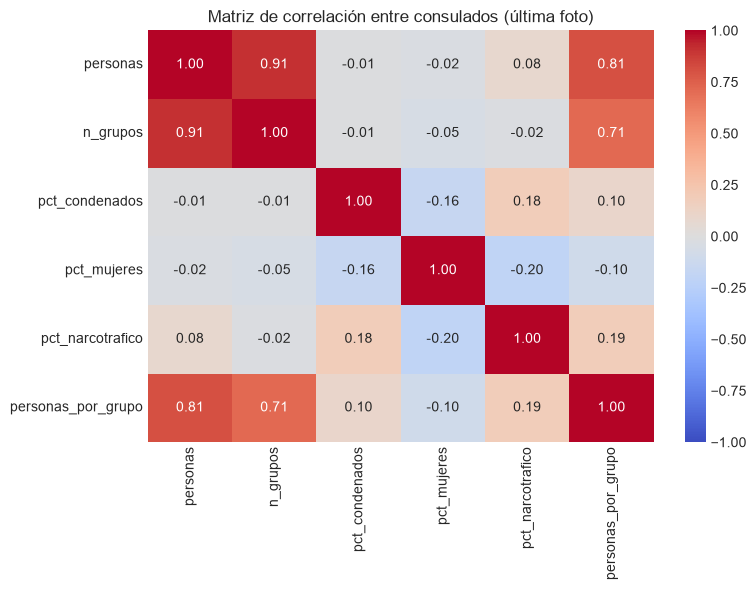

In [67]:
plt.figure(figsize=(8, 6))
sns.heatmap(analisis.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Matriz de correlación entre consulados (última foto)')
plt.tight_layout(); plt.show()

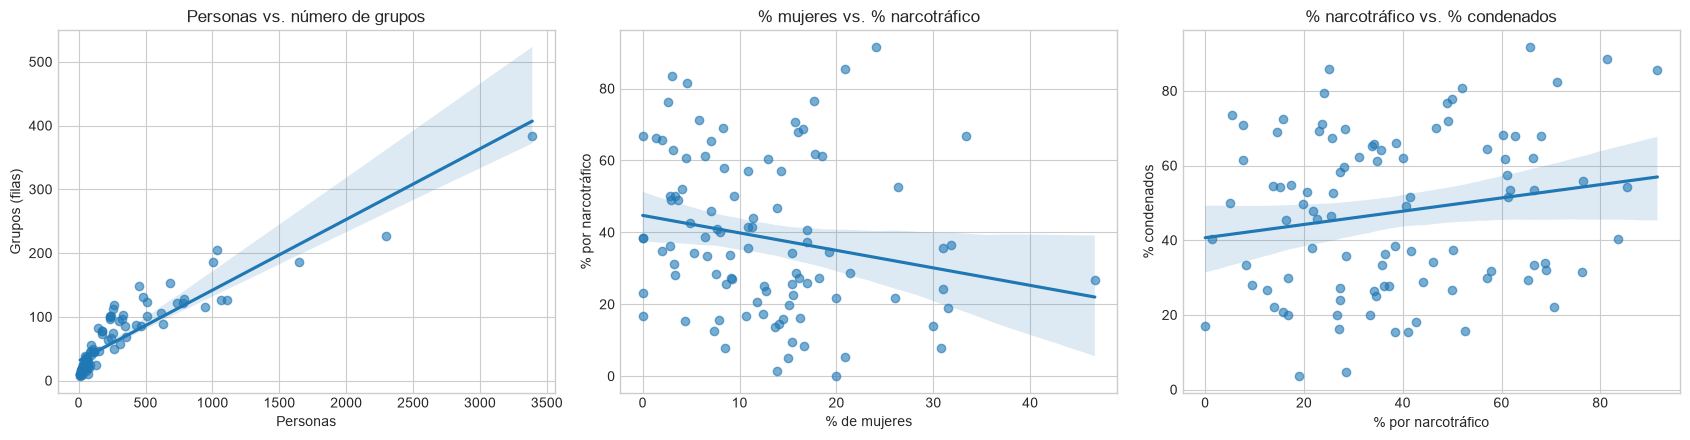

In [68]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

sns.regplot(data=analisis, x='personas', y='n_grupos', scatter_kws={'alpha': 0.6}, ax=axes[0])
axes[0].set_title('Personas vs. número de grupos')
axes[0].set_xlabel('Personas'); axes[0].set_ylabel('Grupos (filas)')

sns.regplot(data=analisis, x='pct_mujeres', y='pct_narcotrafico', scatter_kws={'alpha': 0.6}, ax=axes[1])
axes[1].set_title('% mujeres vs. % narcotráfico')
axes[1].set_xlabel('% de mujeres'); axes[1].set_ylabel('% por narcotráfico')

sns.regplot(data=analisis, x='pct_narcotrafico', y='pct_condenados', scatter_kws={'alpha': 0.6}, ax=axes[2])
axes[2].set_title('% narcotráfico vs. % condenados')
axes[2].set_xlabel('% por narcotráfico'); axes[2].set_ylabel('% condenados')

plt.tight_layout(); plt.show()

In [69]:
sin_raros = analisis.drop(index=['BTA. ASISTENCIA', 'DESCONOCIDA'])
cambio = (sin_raros.corr().round(2) - analisis.corr().round(2)).abs().max().max()
print("Cambio máximo en las correlaciones al quitarlas:", cambio)

Cambio máximo en las correlaciones al quitarlas: 0.039999999999999994


## Análisis bivariado

**Unidad de análisis:** como a nivel de fila solo hay una variable numérica (CANTIDAD), se construyó una tabla con un renglón por consulado en la última foto, con variables derivadas: personas, número de grupos (filas), personas por grupo y el porcentaje de personas condenadas, mujeres y detenidas por narcotráfico. Se excluyeron los consulados con menos de 10 personas (20 de 117), porque un porcentaje sobre muy pocas personas es inestable (con 1 persona sale 0 % o 100 %). Con esto se pierde solo el 0,3 % de las personas.

**Matriz de correlación:** las correlaciones más altas son mecánicas y no hallazgos: personas y grupos (0,91), personas y personas por grupo (0,81) y grupos y personas por grupo (0,71), porque las personas son los grupos multiplicados por las personas por grupo.

**Relaciones débiles:** el resto no pasa de 0,20 en valor absoluto: % mujeres y % narcotráfico (−0,20), % narcotráfico y % condenados (0,18) y % mujeres y % condenados (−0,16). Los diagramas de dispersión lo confirman: las nubes son muy dispersas y la banda de confianza de la recta es ancha. Con 97 consulados, correlaciones de ese tamaño son difíciles de distinguir del ruido.

**Tamaño del consulado:** el número de personas casi no se relaciona con la composición (con % condenados −0,01, con % mujeres −0,02 y con % narcotráfico 0,08).

**Cautelas:** estas correlaciones son entre consulados, no entre personas, y no demuestran causalidad. La tabla incluye dos entradas que no son consulados en el exterior (BTA. ASISTENCIA y DESCONOCIDA). Al quitarlas, ninguna correlación cambia más de 0,04, por lo que se conservaron.

## 5. Agregaciones por grupo

Para las comparaciones siguientes se tomó la **última foto disponible
(01/11/2025)**, que representa 27.586 personas. Esto evita el conteo
múltiple que resultaría de sumar CANTIDAD a través de las 64 fechas
de publicación, ya que cada fecha es una fotografía del mismo universo
de detenidos. Siempre se muestra el conteo de filas junto al total,
porque un promedio de pocas filas no es tan confiable como uno de muchas.

In [70]:
ultima = df['FECHA PUBLICACIÓN'].max()
df_foto = df[df['FECHA PUBLICACIÓN'] == ultima].copy()
print(f"Última foto: {ultima.date()}")
print(f"Filas: {len(df_foto):,}  |  Personas: {df_foto['CANTIDAD'].sum():,}")

Última foto: 2025-11-01
Filas: 6,117  |  Personas: 27,586


### 5.1 Consulados con más detenidos

Top 15 consulados con más colombianos detenidos (01/11/2025)
                  total  filas  % del total
CONSULADO                                  
C. MADRID          3391    384        12.30
C. PANAMA          2301    226         8.30
C. SANTIAGO        1644    186         6.00
C. SAN CRISTOBAL   1106    127         4.00
C. LIMA            1065    126         3.90
C. MEXICO          1037    204         3.80
BTA. ASISTENCIA    1002    186         3.60
C. HOUSTON          946    115         3.40
C. GUAYAQUIL        791    128         2.90
C. BARCELONA        778    121         2.80
C. ORLANDO          736    121         2.70
C. BUENOS AIRES     686    153         2.50
C. ANTOFAGASTA      629     89         2.30
C. SAN JOSE         616    106         2.20
C. VALENCIA VEN     514    101         1.90

Los 15 primeros concentran: 62.5 % de las personas


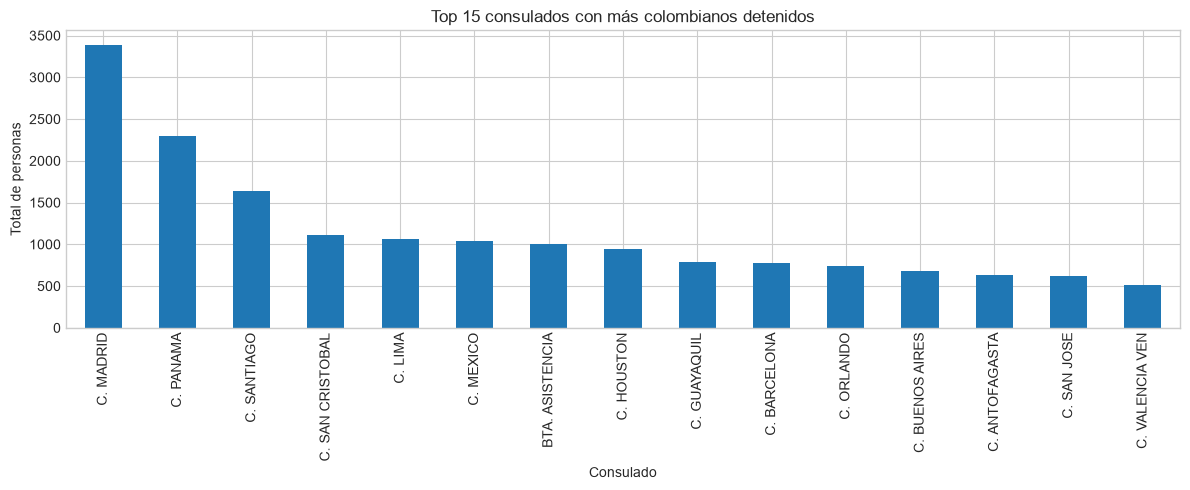

In [71]:
por_consul = (df_foto.groupby('CONSULADO')['CANTIDAD']
              .agg(total='sum', filas='size')
              .sort_values('total', ascending=False))

# peso de cada consulado sobre el total de personas de la foto
por_consul['% del total'] = (por_consul['total'] / por_consul['total'].sum() * 100).round(1)

top15 = por_consul.head(15)
print("Top 15 consulados con más colombianos detenidos (01/11/2025)")
print(top15)
print("\nLos 15 primeros concentran:", round(top15['total'].sum() / por_consul['total'].sum() * 100, 1), "% de las personas")

top15['total'].plot.bar(figsize=(12, 5))
plt.title('Top 15 consulados con más colombianos detenidos')
plt.xlabel('Consulado')
plt.ylabel('Total de personas')
plt.tight_layout()
plt.show()

In [72]:
v = df[(df['CONSULADO'] == 'C. VALENCIA VEN') & (df['PAIS PRISIÓN'] != 'DESCONOCIDO')]
print((v.groupby('PAIS PRISIÓN')['CANTIDAD'].sum() / v['CANTIDAD'].sum() * 100).round(1))

b = df[(df['CONSULADO'] == 'BTA. ASISTENCIA') & (df['PAIS PRISIÓN'] != 'DESCONOCIDO')]
print(b.groupby('PAIS PRISIÓN')['CANTIDAD'].sum().sort_values(ascending=False).head(6))

PAIS PRISIÓN
ITALIA       0.20
VENEZUELA   99.80
Name: CANTIDAD, dtype: float64
PAIS PRISIÓN
ESTADOS UNIDOS    3351
ESPAÑA             558
VENEZUELA          217
ARGENTINA          206
CHILE              186
PANAMA             124
Name: CANTIDAD, dtype: int64


**Consulados con más detenidos (última foto):** Madrid lidera con 3.391 personas (12,3 %), seguido de Panamá (8,3 %) y Santiago (6,0 %). Los 15 primeros consulados reúnen el 62,5 % de las 27.586 personas, así que la distribución está muy concentrada.

**BTA. ASISTENCIA (puesto 7, 1.002 personas):** no es un consulado de un país. En los registros donde sí se reportó el país de prisión aparece asociada a varios países (Estados Unidos, España, Venezuela, Argentina y Chile). **Decisión:** se conserva en el ranking porque son datos reales de detenidos, pero se interpreta como una oficina de asistencia y no como una ubicación.

**C. VALENCIA VEN:** corresponde a Venezuela (en los registros con país reportado, el 99,8 % dice Venezuela) y es distinto de `C. VALENCIA ESP`. Por eso no se suma a Valencia de España ni a los consulados españoles.

### 5.2 Delitos más frecuentes

Detenidos por delito (01/11/2025): los 12 primeros
                                       total  filas  % del total
DELITO                                                          
NARCOTRÁFICO                           11441   1377        41.50
DESCONOCIDO                             4041    589        14.60
ROBO / HURTO                            3248    691        11.80
HOMICIDIO / TENTATIVA DE                1483    485         5.40
OTROS                                   1243    458         4.50
NO REPORTA - CONFIDENCIALIDAD ESTATAL    972    201         3.50
DELITOS SEXUALES                         887    372         3.20
PORTE ILEGAL DE ARMAS                    592    216         2.10
DELITO MIGRATORIO                        548    166         2.00
SECUESTRO                                401    169         1.50
CRIMEN ORGANIZADO                        340    149         1.20
FRAUDE / ESTAFA                          333    151         1.20

Personas sin información de delito: 5,

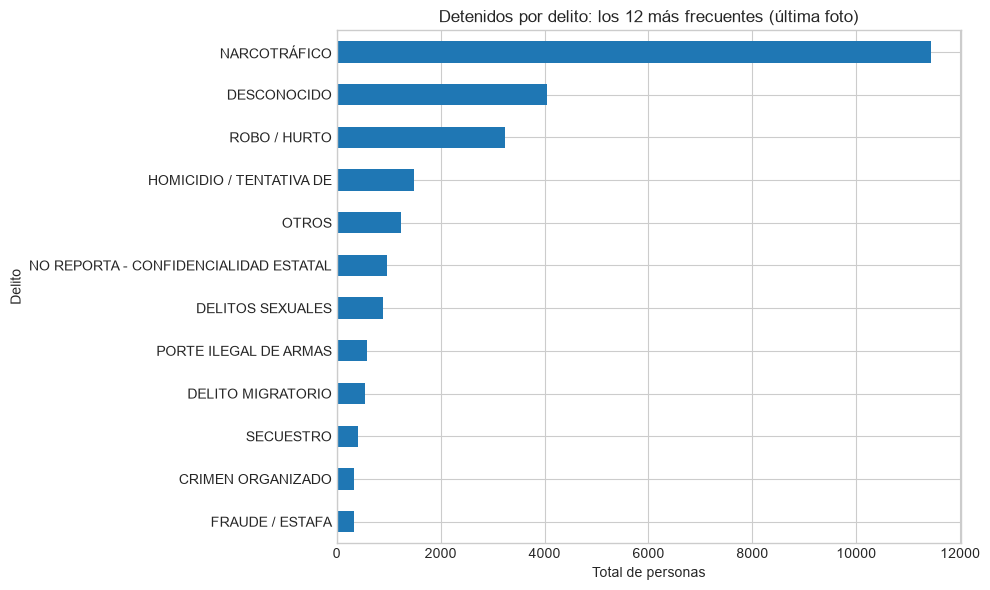

In [73]:
por_delito = (df_foto.groupby('DELITO')['CANTIDAD']
              .agg(total='sum', filas='size')
              .sort_values('total', ascending=False))
por_delito['% del total'] = (por_delito['total'] / por_delito['total'].sum() * 100).round(1)

print("Detenidos por delito (01/11/2025): los 12 primeros")
print(por_delito.head(12))

# delitos sin información: no sabemos qué delito es
sin_info = por_delito.loc[['DESCONOCIDO', 'NO REPORTA - CONFIDENCIALIDAD ESTATAL'], 'total'].sum()
total = por_delito['total'].sum()
print(f"\nPersonas sin información de delito: {sin_info:,} ({sin_info / total * 100:.1f} %)")
narco = por_delito.loc['NARCOTRÁFICO', 'total']
print(f"Narcotráfico entre las personas con delito reportado: {narco / (total - sin_info) * 100:.1f} %")

por_delito['total'].head(12).sort_values().plot.barh(figsize=(10, 6))
plt.title('Detenidos por delito: los 12 más frecuentes (última foto)')
plt.xlabel('Total de personas')
plt.ylabel('Delito')
plt.tight_layout()
plt.show()

**Delitos (última foto):** el narcotráfico es el delito más frecuente: 11.441 personas, el 41,5 %. Le siguen robo/hurto (11,8 %) y homicidio o tentativa (5,4 %). Hay que leer el ranking con cuidado, porque de 5.013 personas (18,2 %) no sabemos el delito: 4.041 aparecen como `DESCONOCIDO` y 972 como `NO REPORTA - CONFIDENCIALIDAD ESTATAL`. Entre las personas con delito reportado, el narcotráfico sube al 50,7 %.

**Decisión:** se conservan esas dos categorías y no se imputa nada. El 41,5 % es sobre todas las personas de la foto, y el 50,7 % es sobre las que tienen delito conocido; la conclusión debe decir cuál de los dos se usa.

### 5.3 Delitos dentro de los consulados con más detenidos

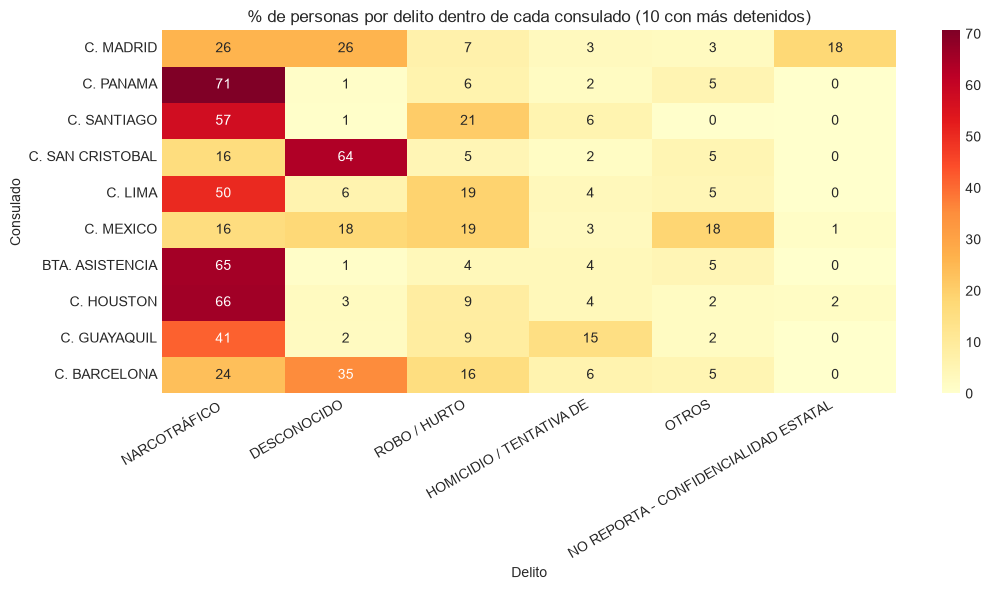

% sin información de delito, por consulado:
CONSULADO
C. SAN CRISTOBAL   63.70
C. MADRID          44.00
C. BARCELONA       35.60
C. MEXICO          18.80
C. LIMA             6.10
C. HOUSTON          4.20
C. GUAYAQUIL        2.50
BTA. ASISTENCIA     1.00
C. PANAMA           0.90
C. SANTIAGO         0.80
dtype: float64


In [74]:
top10 = por_consul.head(10).index
delitos_top = por_delito.head(6).index          # los 6 delitos con más personas

sub = df_foto[df_foto['CONSULADO'].isin(top10)]
tabla = sub.pivot_table(index='CONSULADO', columns='DELITO', values='CANTIDAD',
                        aggfunc='sum', fill_value=0).loc[top10]
pct = tabla.div(tabla.sum(axis=1), axis=0) * 100      # % dentro de cada consulado

plt.figure(figsize=(11, 6))
sns.heatmap(pct[delitos_top], annot=True, fmt='.0f', cmap='YlOrRd')
plt.title('% de personas por delito dentro de cada consulado (10 con más detenidos)')
plt.xlabel('Delito'); plt.ylabel('Consulado')
plt.xticks(rotation=30, ha='right')
plt.tight_layout(); plt.show()

sin_info_cols = ['DESCONOCIDO', 'NO REPORTA - CONFIDENCIALIDAD ESTATAL']
print("% sin información de delito, por consulado:")
print(pct[sin_info_cols].sum(axis=1).round(1).sort_values(ascending=False))

**Delitos dentro de los consulados con más detenidos:** el perfil cambia mucho de un consulado a otro. El narcotráfico domina en Panamá (71 %), Houston (66 %) y BTA. Asistencia (65 %), y también pesa en Santiago (57 %) y Lima (50 %). Santiago y Lima tienen además mucho robo/hurto (21 % y 19 %), y en Guayaquil el homicidio o tentativa llega al 15 %.

**Cautela:** en Madrid el narcotráfico es solo el 26 %, pero el 44 % de sus personas no tiene delito conocido (26 % `DESCONOCIDO` y 18 % `NO REPORTA`). En San Cristóbal el 64 % es `DESCONOCIDO` y en Barcelona el 36 % no tiene delito conocido. En esos tres consulados no se puede concluir qué delitos predominan, porque falta la información.

### 5.4 Evolución en el tiempo (pregunta 2)

Primera y última foto
                   personas  % narcotráfico  % condenados  % en investigación  \
FECHA PUBLICACIÓN                                                               
2018-09-17            23284           46.90         52.70               36.70   
2025-11-01            27586           41.50         47.10               40.00   

                   % mujeres  % delito desconocido  
FECHA PUBLICACIÓN                                   
2018-09-17             12.50                 13.50  
2025-11-01             12.20                 14.60  

Cambio en personas entre la primera y la última foto: 18.5 %
Foto con más personas: 2022-12-05 (28,058)

Última foto de cada año
                   personas  % narcotráfico  % condenados  % en investigación  \
FECHA PUBLICACIÓN                                                               
2018-09-17            23284           46.90         52.70               36.70   
2019-09-11            25506           45.20         51.50           

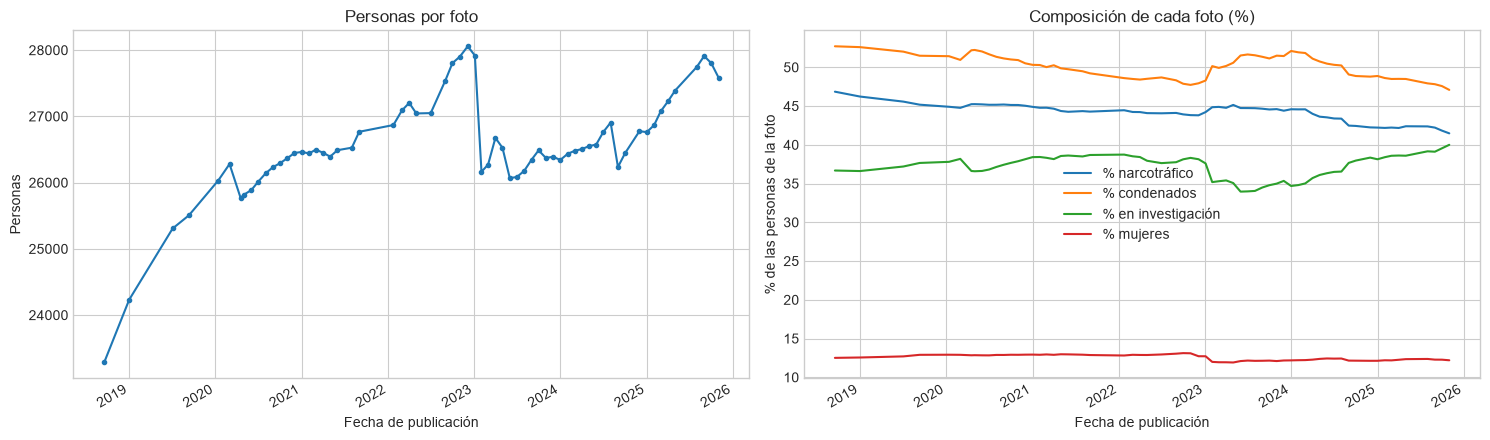

In [75]:
total_foto = df.groupby('FECHA PUBLICACIÓN')['CANTIDAD'].sum()

def pct_foto(columna, valor):
    # % de las personas de cada foto que cumplen una condición
    suma = df[df[columna] == valor].groupby('FECHA PUBLICACIÓN')['CANTIDAD'].sum()
    return suma.reindex(total_foto.index).fillna(0) / total_foto * 100

evolucion = pd.DataFrame({
    'personas': total_foto,
    '% narcotráfico': pct_foto('DELITO', 'NARCOTRÁFICO'),
    '% condenados': pct_foto('SITUACIÓN JURÍDICA', 'CONDENADO'),
    '% en investigación': pct_foto('SITUACIÓN JURÍDICA', 'EN INVESTIGACIÓN'),
    '% mujeres': pct_foto('GÉNERO', 'FEMENINO'),
    '% delito desconocido': pct_foto('DELITO', 'DESCONOCIDO'),
})

print("Primera y última foto")
print(evolucion.iloc[[0, -1]].round(1))
cambio_total = (evolucion['personas'].iloc[-1] / evolucion['personas'].iloc[0] - 1) * 100
print(f"\nCambio en personas entre la primera y la última foto: {cambio_total:.1f} %")
print("Foto con más personas:", evolucion['personas'].idxmax().date(), f"({evolucion['personas'].max():,})")

print("\nÚltima foto de cada año")
print(evolucion.groupby(evolucion.index.year).tail(1).round(1))

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
evolucion['personas'].plot(ax=axes[0], marker='o', markersize=3)
axes[0].set_title('Personas por foto')
axes[0].set_xlabel('Fecha de publicación'); axes[0].set_ylabel('Personas')
evolucion[['% narcotráfico', '% condenados', '% en investigación', '% mujeres']].plot(ax=axes[1])
axes[1].set_title('Composición de cada foto (%)')
axes[1].set_xlabel('Fecha de publicación'); axes[1].set_ylabel('% de las personas de la foto')
plt.tight_layout(); plt.show()

**Cómo se hizo:** aquí no se suman las fotos: cada punto es una foto completa, y lo que se compara es el total y el porcentaje dentro de cada una.

**Total:** pasó de 23.284 personas (17/09/2018) a 27.586 (01/11/2025), un aumento de 18,5 %. No es una subida continua: el máximo fue 28.058 el 05/12/2022 y la última foto de 2023 fue de 26.390.

**Composición:** el porcentaje de narcotráfico bajó de 46,9 % a 41,5 %, y el de condenados de 52,7 % a 47,1 %, mientras que el de personas en investigación subió de 36,7 % a 40,0 %. El porcentaje de mujeres casi no se movió (12,5 % a 12,2 %).

**Cautelas:** 2018 es una sola foto (la del 17/09), así que el punto de partida es un solo dato. Además, el porcentaje de delito `DESCONOCIDO` subió de 13,5 % a 14,6 %, y eso puede mover un poco los demás porcentajes. Los datos muestran que cambió la composición, pero no explican por qué.

Consulados con registros: 2018 = 111 | 2025 = 117

Los que más aumentaron
                 2018 (17/09)  2025 (01/11)  cambio
CONSULADO                                          
C. MADRID                2294          3391    1097
C. PANAMA                1433          2301     868
C. SANTIAGO              1003          1644     641
BTA. ASISTENCIA           433          1002     569
C. MEXICO                 621          1037     416

Los que más disminuyeron
               2018 (17/09)  2025 (01/11)  cambio
CONSULADO                                        
C. QUITO               1053           479    -574
C. ATLANTA             1026           463    -563
C. TULCAN               652           116    -536
C. ESMERALDAS           575            89    -486
C. GUAYAQUIL           1024           791    -233


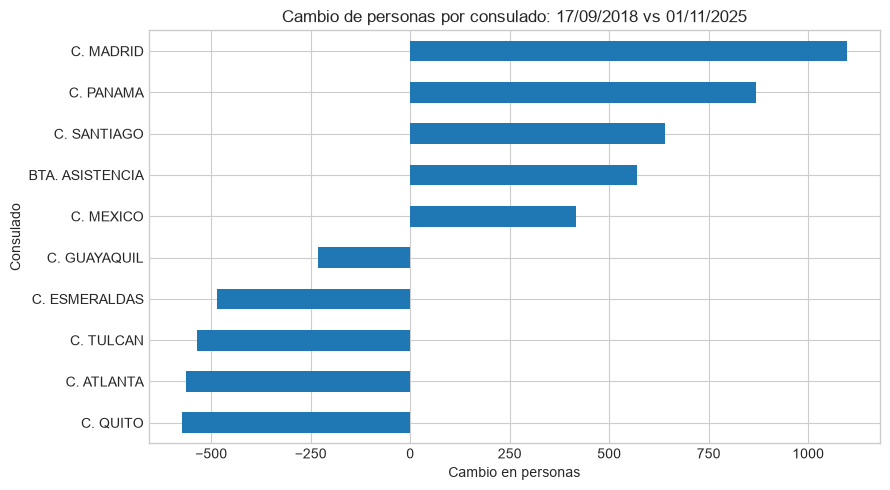

In [76]:
primera = df[df['FECHA PUBLICACIÓN'] == df['FECHA PUBLICACIÓN'].min()]
cambio = pd.DataFrame({
    '2018 (17/09)': primera.groupby('CONSULADO')['CANTIDAD'].sum(),
    '2025 (01/11)': df_foto.groupby('CONSULADO')['CANTIDAD'].sum(),
}).fillna(0).astype(int)
cambio['cambio'] = cambio['2025 (01/11)'] - cambio['2018 (17/09)']

print("Consulados con registros: 2018 =", (cambio['2018 (17/09)'] > 0).sum(),
      "| 2025 =", (cambio['2025 (01/11)'] > 0).sum())
print("\nLos que más aumentaron")
print(cambio.sort_values('cambio', ascending=False).head(5))
print("\nLos que más disminuyeron")
print(cambio.sort_values('cambio').head(5))

extremos = pd.concat([cambio.sort_values('cambio').head(5),
                      cambio.sort_values('cambio').tail(5)])
extremos['cambio'].plot.barh(figsize=(9, 5))
plt.title('Cambio de personas por consulado: 17/09/2018 vs 01/11/2025')
plt.xlabel('Cambio en personas')
plt.ylabel('Consulado')
plt.tight_layout(); plt.show()

**Cambios por consulado (2018 frente a 2025):** los que más crecieron fueron Madrid (+1.097), Panamá (+868), Santiago (+641), BTA. Asistencia (+569) y México (+416). Los que más bajaron fueron Quito (−574), Atlanta (−563), Tulcán (−536) y Esmeraldas (−486); de estos, tres son consulados de Ecuador. Guayaquil, también en Ecuador, bajó 233.

**Cautela:** es una comparación entre solo dos fotos, no una tendencia. Un cambio de consulado puede deberse a que se movieron las personas o a cómo se registran, y los datos no permiten distinguirlo.

### 5.5 Diferencias por género (pregunta 3)

Se compara `MASCULINO` con `FEMENINO`, porque las otras tres categorías (`OTRO`, `DESCONOCIDO` y `NO_BINARIO`) suman solo 14 personas en la última foto y no alcanzan para comparar. Las tablas muestran el % dentro de cada género, no el total, porque hay muchos más hombres que mujeres.

Personas por género: {'DESCONOCIDO': 3, 'FEMENINO': 3363, 'MASCULINO': 24209, 'NO_BINARIO': 2, 'OTRO': 9}
Mujeres: 12.2 % del total de la foto

% por delito dentro de cada género
GÉNERO                                 FEMENINO  MASCULINO  dif (F - M)
DELITO                                                                 
NARCOTRÁFICO                              40.70      41.60        -0.80
DESCONOCIDO                               17.20      14.30         3.00
ROBO / HURTO                               9.50      12.10        -2.60
HOMICIDIO / TENTATIVA DE                   2.80       5.70        -2.90
OTROS                                      5.40       4.40         1.10
NO REPORTA - CONFIDENCIALIDAD ESTATAL      5.10       3.30         1.70
DELITOS SEXUALES                           1.00       3.50        -2.50
PORTE ILEGAL DE ARMAS                      0.90       2.30        -1.40
DELITO MIGRATORIO                          4.80       1.60         3.20
SECUESTRO                    

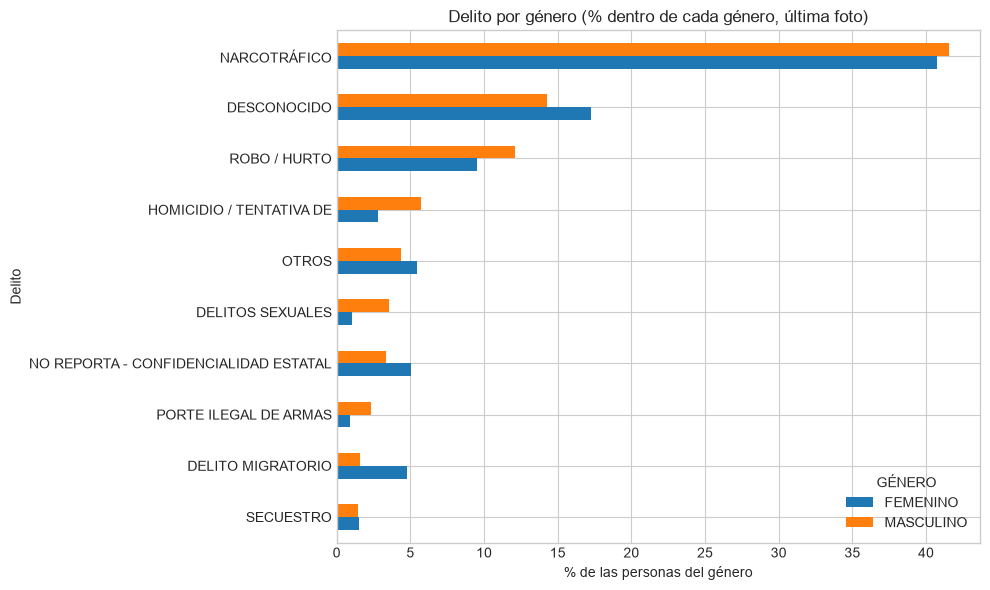

In [77]:
mf = df_foto[df_foto['GÉNERO'].isin(['MASCULINO', 'FEMENINO'])]
print("Personas por género:", df_foto.groupby('GÉNERO')['CANTIDAD'].sum().to_dict())
muj = mf[mf['GÉNERO'] == 'FEMENINO']['CANTIDAD'].sum()
print(f"Mujeres: {muj / df_foto['CANTIDAD'].sum() * 100:.1f} % del total de la foto")

# Delito: % dentro de cada género
delito_gen = mf.pivot_table(index='DELITO', columns='GÉNERO', values='CANTIDAD',
                            aggfunc='sum', fill_value=0)
delito_pct = delito_gen.div(delito_gen.sum(axis=0), axis=1) * 100
delito_pct['dif (F - M)'] = delito_pct['FEMENINO'] - delito_pct['MASCULINO']
top_del = por_delito.head(10).index
print("\n% por delito dentro de cada género")
print(delito_pct.loc[top_del].round(1))

delito_pct.loc[top_del, ['FEMENINO', 'MASCULINO']].sort_values('MASCULINO').plot.barh(figsize=(10, 6))
plt.title('Delito por género (% dentro de cada género, última foto)')
plt.xlabel('% de las personas del género')
plt.ylabel('Delito')
plt.tight_layout(); plt.show()

% por situación jurídica dentro de cada género
GÉNERO                                 FEMENINO  MASCULINO
SITUACIÓN JURÍDICA                                        
CONDENADO                                 39.00      48.20
EN ESPERA DE DEPORTACIÓN                   3.50       2.00
EN INVESTIGACIÓN                          45.10      39.30
EN JUICIO                                  7.80       8.10
EXTRADITADO                                0.20       0.00
NO REPORTA - CONFIDENCIALIDAD ESTATAL      4.40       2.30


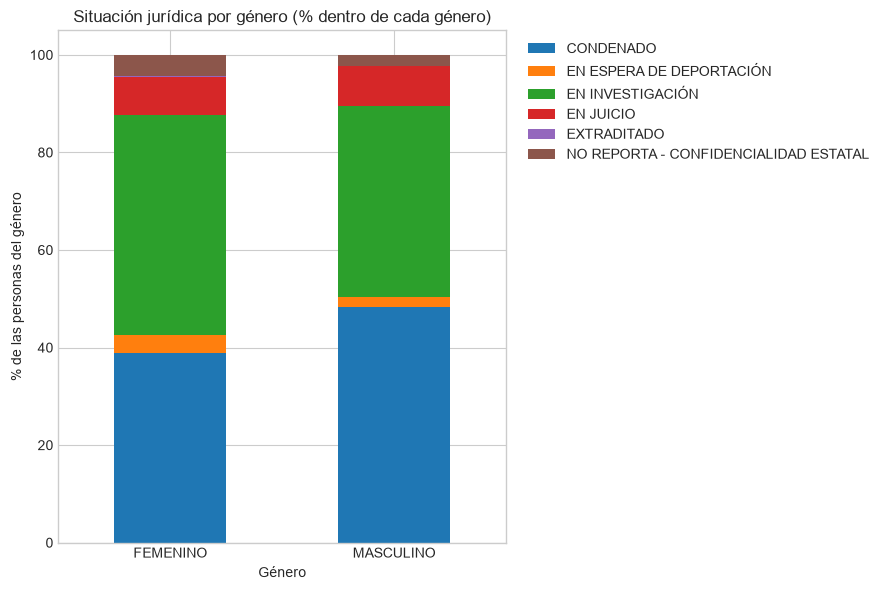

In [78]:
sit_gen = mf.pivot_table(index='SITUACIÓN JURÍDICA', columns='GÉNERO', values='CANTIDAD',
                         aggfunc='sum', fill_value=0)
sit_pct = sit_gen.div(sit_gen.sum(axis=0), axis=1) * 100
print("% por situación jurídica dentro de cada género")
print(sit_pct.round(1))

sit_pct.T.plot.bar(stacked=True, figsize=(9, 6))
plt.title('Situación jurídica por género (% dentro de cada género)')
plt.xlabel('Género')
plt.ylabel('% de las personas del género')
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout(); plt.show()

In [79]:
# ¿La diferencia de narcotráfico entre géneros se mantiene dentro de cada consulado?
filas = []
for c in por_consul.head(8).index:
    y = mf[mf['CONSULADO'] == c]
    fila = {'CONSULADO': c}
    for gen in ['FEMENINO', 'MASCULINO']:
        z = y[y['GÉNERO'] == gen]
        fila[f'% narco {gen[0]}'] = round(z[z['DELITO'] == 'NARCOTRÁFICO']['CANTIDAD'].sum() / z['CANTIDAD'].sum() * 100, 1)
        fila[f'personas {gen[0]}'] = z['CANTIDAD'].sum()
    filas.append(fila)
print(pd.DataFrame(filas).set_index('CONSULADO'))

                  % narco F  personas F  % narco M  personas M
CONSULADO                                                     
C. MADRID             33.00         576      24.50        2815
C. PANAMA             56.60         362      73.30        1937
C. SANTIAGO           76.00         179      54.80        1464
C. SAN CRISTOBAL      40.60         180      11.60         926
C. LIMA               67.00         100      48.50         964
C. MEXICO             12.00         150      16.50         887
BTA. ASISTENCIA       45.10          71      66.80         931
C. HOUSTON            26.30          19      66.60         927


**Género y delito:** las mujeres son el 12,2 % de las personas de la foto. En narcotráfico casi no hay diferencia: 40,7 % de las mujeres y 41,6 % de los hombres. Donde sí hay diferencia es en otros delitos: los hombres tienen más homicidio o tentativa (5,7 % frente a 2,8 %), robo/hurto (12,1 % frente a 9,5 %) y delitos sexuales (3,5 % frente a 1,0 %), y las mujeres más delito migratorio (4,8 % frente a 1,6 %). También hay más mujeres con delito `DESCONOCIDO` (17,2 % frente a 14,3 %).

**Género y situación jurídica:** el 48,2 % de los hombres está condenado, frente al 39,0 % de las mujeres. En cambio, el 45,1 % de las mujeres está en investigación, frente al 39,3 % de los hombres.

**Chequeo por consulado:** que el narcotráfico sea casi igual en total no significa que sea igual en todos lados. Dentro de cada consulado la diferencia es grande y va en direcciones distintas: en Santiago es 76 % en mujeres y 55 % en hombres, y en San Cristóbal 41 % y 12 %; en Panamá es al revés, 57 % en mujeres y 73 % en hombres, y lo mismo pasa en BTA. Asistencia (45 % y 67 %). En Houston hay solo 19 mujeres, así que ese dato es poco fiable. El promedio general esconde esas diferencias.

**Cautelas:** estas diferencias son entre grupos de una sola foto y no demuestran que el género cause nada. La edad, el tiempo de detención y el consulado también pueden influir.

### 5.6 Situación jurídica por edad

Se comparan porcentajes dentro de cada grupo de edad y no totales, porque los grupos tienen tamaños muy distintos. Los grupos con menos de 100 personas (`ADOLESCENTE`, `INFANTE` y `PRIMERA INFANCIA`, de 16 a 33 personas cada uno) se dejan fuera de la gráfica.

Personas y % de situación jurídica dentro de cada grupo de edad
                  total  CONDENADO  EN ESPERA DE DEPORTACIÓN  \
GRUPO EDAD                                                     
ADOLESCENTE          17      41.20                      0.00   
ADULTO            14561      53.90                      2.20   
ADULTO JOVEN       1937      28.40                      2.90   
ADULTO MAYOR       2484      66.10                      1.70   
DESCONOCIDO        8538      34.20                      2.30   
INFANTE              16      43.80                      0.00   
PRIMERA INFANCIA     33      30.30                      6.10   

                  EN INVESTIGACIÓN  EN JUICIO  EXTRADITADO  \
GRUPO EDAD                                                   
ADOLESCENTE                  52.90       5.90         0.00   
ADULTO                       34.40       7.20         0.10   
ADULTO JOVEN                 60.40       7.10         0.00   
ADULTO MAYOR                 24.90       4.70    

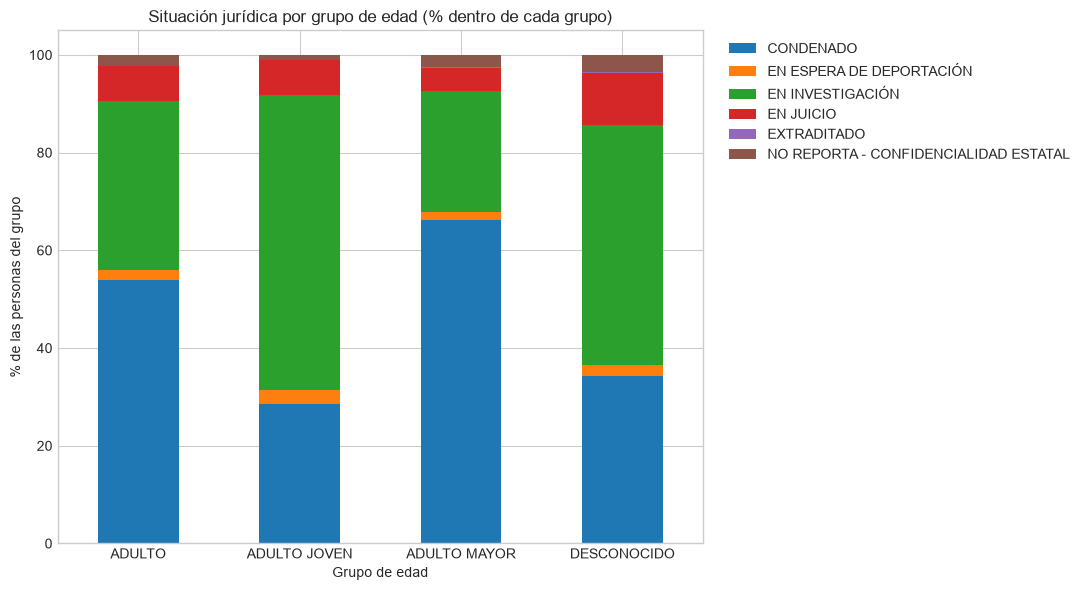

In [80]:
edad_sit = df_foto.pivot_table(index='GRUPO EDAD', columns='SITUACIÓN JURÍDICA',
                               values='CANTIDAD', aggfunc='sum', fill_value=0)
edad_sit['total'] = edad_sit.sum(axis=1)
pct_edad = edad_sit.drop(columns='total').div(edad_sit['total'], axis=0) * 100

print("Personas y % de situación jurídica dentro de cada grupo de edad")
print(pd.concat([edad_sit['total'], pct_edad.round(1)], axis=1))

# los grupos con menos de 100 personas no sirven para comparar porcentajes
grandes = edad_sit.index[edad_sit['total'] >= 100]
print("\nGrupos comparados:", list(grandes))

pct_edad.loc[grandes].plot.bar(stacked=True, figsize=(11, 6))
plt.title('Situación jurídica por grupo de edad (% dentro de cada grupo)')
plt.xlabel('Grupo de edad')
plt.ylabel('% de las personas del grupo')
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout(); plt.show()

**Resultado:** el 66,1 % de los adultos mayores está condenado, frente al 53,9 % de los adultos y el 28,4 % de los adultos jóvenes. En los adultos jóvenes predomina la investigación (60,4 %).

**Cautela:** el 31 % de las personas no tiene edad conocida, así que estas cifras describen solo a quienes sí la tienen. Que los adultos mayores estén más condenados puede deberse a que llevan más tiempo detenidos, pero los datos no lo muestran.

## 6. Conclusiones

**Pregunta 1: ¿en qué consulados hay más detenidos y por qué delitos?**
Los detenidos están muy concentrados. En la última foto (01/11/2025) hay 27.586 personas en 117 consulados; Madrid tiene 3.391 (12,3 %), Panamá 2.301 (8,3 %) y Santiago 1.644 (6,0 %), y los 15 primeros reúnen el 62,5 %. El delito más frecuente es el narcotráfico: 41,5 % de todas las personas y 50,7 % de las que tienen delito reportado. Le siguen robo/hurto (11,8 %) y homicidio o tentativa (5,4 %). El perfil depende del consulado: narcotráfico en Panamá (71 %), Houston (66 %) y BTA. Asistencia (65 %), y más robo/hurto en Santiago y Lima.

**Pregunta 2: ¿cómo cambió el total y la composición entre 2018 y 2025?**
El total subió 18,5 %, de 23.284 a 27.586 personas, con un máximo de 28.058 en diciembre de 2022. La composición cambió poco pero con una dirección clara: el narcotráfico bajó de 46,9 % a 41,5 %, los condenados de 52,7 % a 47,1 % y las personas en investigación subieron de 36,7 % a 40,0 %. El porcentaje de mujeres se mantuvo cerca del 12 %. Madrid, Panamá y Santiago son los consulados que más crecieron, y Quito, Atlanta, Tulcán y Esmeraldas los que más bajaron.

**Pregunta 3: ¿hay diferencias por género en delito y situación jurídica?**
Sí, en parte. En narcotráfico casi no hay diferencia general (40,7 % mujeres, 41,6 % hombres), pero los hombres tienen más homicidio, robo y delitos sexuales, y las mujeres más delito migratorio. En situación jurídica, el 48,2 % de los hombres está condenado frente al 39,0 % de las mujeres, y el 45,1 % de las mujeres está en investigación frente al 39,3 % de los hombres. Dentro de cada consulado el narcotráfico por género varía mucho y en direcciones distintas, así que la igualdad general no se cumple en todos lados.

**Limitaciones que condicionan estas respuestas**
- Cada fila es un grupo de personas dentro de una foto, y cada foto cuenta a las mismas personas. Por eso nunca se sumaron las 64 fotos; se usó la última foto o se comparó foto contra foto.
- Desde 2023 el país de prisión no se reporta (queda como `DESCONOCIDO` en todas las personas). La ubicación se analizó con `CONSULADO`, que es una aproximación al país.
- El 18,2 % de las personas no tiene delito conocido y el 31 % no tiene grupo de edad, así que las conclusiones por delito y por edad describen solo a quienes sí tienen el dato.
- Todo son comparaciones entre grupos. Las correlaciones y las diferencias no demuestran causas.